In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from omegaconf.resolvers.oc.dict import values

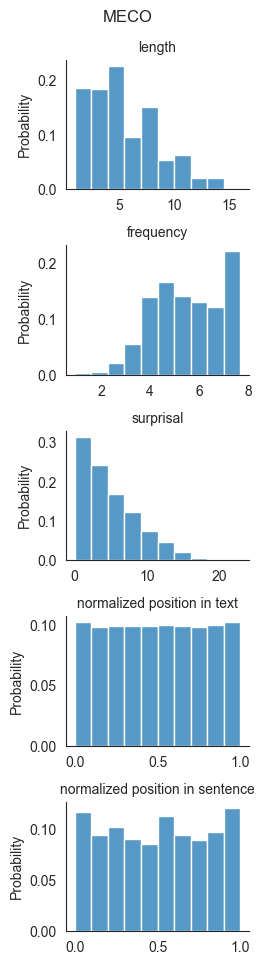

<Figure size 640x480 with 0 Axes>

In [54]:
# Distribution of predictors

model = 'gpt-4o-mini'
corpus = 'meco'
corpus_map = {
    'provo': 'Provo',
    'meco': 'MECO',
    'onestop': 'OneStop'}
IV = ['length', 'frequency', 'surprisal', 'norm_ianum', 'norm_word_pos']
iv_map = {'length': 'length',
          'frequency': 'frequency',
          'surprisal': 'surprisal',
          'norm_ianum': 'normalized position in text',
          'norm_word_pos': 'normalized position in sentence'}
model_type = '_MinusOne'
corpus_run_map = {'provo': 4,
                  'meco': 10,
                  'onestop': 7}

df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_words_plus_triplets_{model}_{corpus_run_map[corpus]}.csv')
values, predictor = [],[]
for iv in IV:
    values.extend(df[iv].tolist())
    predictor.extend([iv_map[iv] for value in df[iv].tolist()])
df = pd.DataFrame({'value': values,
                   'predictor': predictor})

sns.set_style("white")
graph = sns.FacetGrid(
    df,
    col="predictor",
    col_wrap=1,
    height=2,
    aspect=1.4,
    sharex=False,
    sharey=False
)
graph.map_dataframe(
    sns.histplot,
    x="value",
    stat="probability",
    bins=10
)

for ax in graph.axes.flatten():
    ax.tick_params(labelbottom=True)

graph.set_axis_labels("")
graph.set_titles("{col_name}")
# set big title
graph.fig.suptitle(corpus_map[corpus])
# adjust location of graphs so title is not on top of other text
graph.fig.subplots_adjust(top=.93)

plt.savefig(f'../data/analysis/gpt-4o-mini/{corpus}/dist_predictors.png', dpi=300, bbox_inches="tight")
plt.show()
plt.clf()

In [75]:
# Mean and sdt number of triplets per text/sentence
model = 'gpt-4o-mini'
corpus = 'meco'
model_type = '_MinusOne'
corpus_run_map = {'provo': 4,
                  'meco': 10,
                  'onestop': 7}

df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_words_plus_triplets_{model}_{corpus_run_map[corpus]}.csv')
n_new_triplets_text, n_new_triplets_sent = [], []
for text, words in df.groupby('text_id'):
    n_new_triplets_text.append(words['n_new_triplets'].sum())
    for sent, sent_words in words.groupby('sent_id'):
        n_new_triplets_sent.append(sent_words['n_new_triplets'].sum())
print(np.mean(n_new_triplets_text), np.std(n_new_triplets_text), len(n_new_triplets_text))
print(np.mean(n_new_triplets_sent), np.std(n_new_triplets_sent), len(n_new_triplets_sent))
print(np.mean(df['n_new_triplets']), np.std(df['n_new_triplets']), len(df['n_new_triplets']))

21.083333333333332 6.1570871540219585 12
2.504950495049505 1.5582661243770088 101
0.12007593735168486 0.40207151539046304 2107


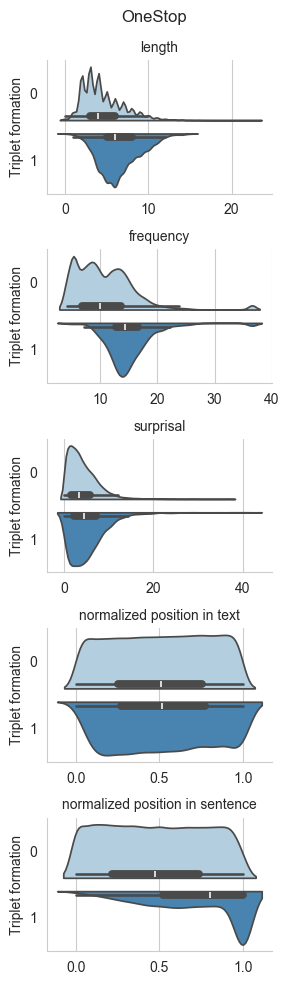

In [28]:
# Distribution triplet formation x co-predictor values
model = 'gpt-4o-mini'
corpus = 'onestop'
model_type = '_MinusOne'
corpus_map = {
    'provo': 'Provo',
    'meco': 'MECO',
    'onestop': 'OneStop'}
corpus_run_map = {'provo': 4,
                  'meco': 10,
                  'onestop': 7}
IV = ['length', 'frequency', 'surprisal', 'norm_ianum', 'norm_word_pos']
iv_map = {'length': 'length',
          'frequency': 'frequency',
          'surprisal': 'surprisal',
          'norm_ianum': 'normalized position in text',
          'norm_word_pos': 'normalized position in sentence'}

df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_words_plus_triplets_{model}_{corpus_run_map[corpus]}.csv')
df['triplet_added'] = df['triplet_added'].astype(str)
triplet_added, co_predictor, co_predictor_value = [], [], []
for iv in IV:
    triplet_added.extend(df['triplet_added'].tolist())
    co_predictor_value.extend(df[iv].tolist())
    co_predictor.extend([iv_map[iv] for v in df['triplet_added'].tolist()])
sns.set_style("whitegrid")
graph = sns.catplot(x=co_predictor_value,
                    y=triplet_added,
                    col=co_predictor,
                    kind='violin',
                    col_wrap=1,
                    split=True,
                    height=2,
                    aspect=1.4,
                    sharex=False,
                    hue=triplet_added,
                    legend=False,
                    palette='Blues')
graph.set_axis_labels("","Triplet formation")
graph.set_titles("{col_name}")
graph.fig.suptitle(corpus_map[corpus])
graph.fig.subplots_adjust(top=.93)
plt.savefig(f'../data/analysis/gpt-4o-mini/{corpus}/dist_triplet_co_predictors.png', dpi=300, bbox_inches="tight")

In [9]:
# Merge data from corpora
model = 'gpt-4o-mini'
corpus_run_map = {'provo': 4,
                  'meco': 10,
                  'onestop': 7}

datasets = []
for corpus, model_run in corpus_run_map.items():
    df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_words_plus_triplets_{model}_{model_run}.csv')
    df['corpus'] = [corpus for i in range(len(df))]
    datasets.append(df)
df = pd.concat(datasets,ignore_index=True)
df.dropna(subset=['n_new_triplets'], inplace=True)
df['ianum_bin'] = pd.cut(df['ianum'], bins=10)
grouped = df.groupby(['ianum_bin', 'corpus']).agg(mean_triplets=('n_triplets', 'mean'),
                                                  std_triplets=('n_triplets', 'std'),
                                                  count=('ianum', 'count')).reset_index()
grouped['ianum_bin'] = grouped['ianum_bin'].astype(str)

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_86467/3592072019.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['ianum_bin', 'corpus']).agg(mean_triplets=('n_triplets', 'mean'),


In [ ]:
# Number of triplets per absolute word position in text with size of dots representing data points
# df['ianum_bin'] = df.groupby('corpus')['ianum'].transform(lambda x: pd.cut(x, bins=10))
sns.set_style('whitegrid')
palette = sns.color_palette("tab10", n_colors=grouped['corpus'].nunique())
corpus_colors = dict(zip(grouped['corpus'].unique(), palette))
plt.figure(figsize=(10, 6))
graph = sns.scatterplot(data=grouped, x='ianum_bin', y='mean_triplets', size='count', hue='corpus', sizes=(30, 300), palette=corpus_colors, alpha=0.5)
for i in range(grouped.shape[0]):
    row = grouped.iloc[i]
    plt.errorbar(x=row['ianum_bin'],y=row['mean_triplets'],yerr=row['std_triplets'] if pd.notnull(row['std_triplets']) else 0,
                 fmt='none',ecolor=corpus_colors[row['corpus']],capsize=3, alpha=0.5)
plt.xticks(rotation=45)
plt.title('Mean Number of Triplets by Word Position and Corpus')
plt.xlabel('Absolute Word Position')
plt.ylabel('Number of Triplets')
# plt.tight_layout()
plt.show()
plt.clf()

In [ ]:
# Check how close each run is from each other
corpus_name = 'onestop'
model_name = 'gpt-4o-mini'
df_corpus = pd.read_csv(f'../data/output/{model_name}/{corpus_name}/{corpus_name}_words_plus_triplets_{model_name}.csv')
df_corpus.dropna(subset=['n_triplets'], inplace=True)

triplet_runs = []
for run_id, rows in df_corpus.groupby('run_id'):
    triplet_runs.append(rows['n_triplets'].values)

# stack data for easier processing (n_runs x n_words)
data_matrix = np.stack(triplet_runs)

# compute pairwise correlations (n_runs x n_runs)
correlation_matrix = np.corrcoef(data_matrix)

# plot correlations in heatmap
plt.figure(figsize=(10, 8))
graph = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', xticklabels=[f'{i}' for i in range(1, len(df_corpus['run_id'].unique())+1)], yticklabels=[f'{i}' for i in range(1, len(df_corpus['run_id'].unique())+1)])
graph.invert_yaxis()
plt.title('Pearson Correlation Heatmap Between Triplet Generation Runs')
plt.tight_layout()
plt.savefig(f'../data/analysis/{model_name}/{corpus_name}/correlation_between_runs_heatmap.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

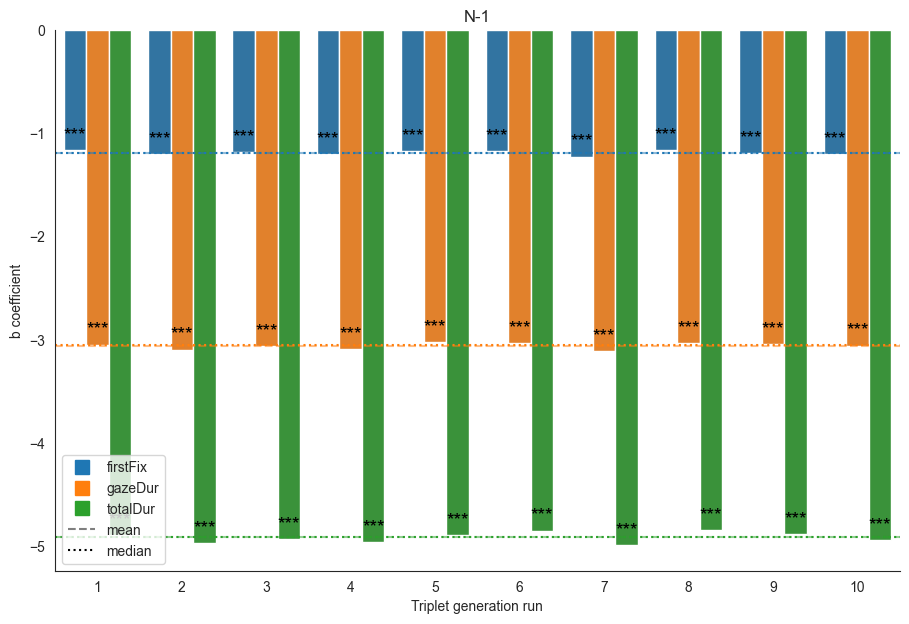

<Figure size 640x480 with 0 Axes>

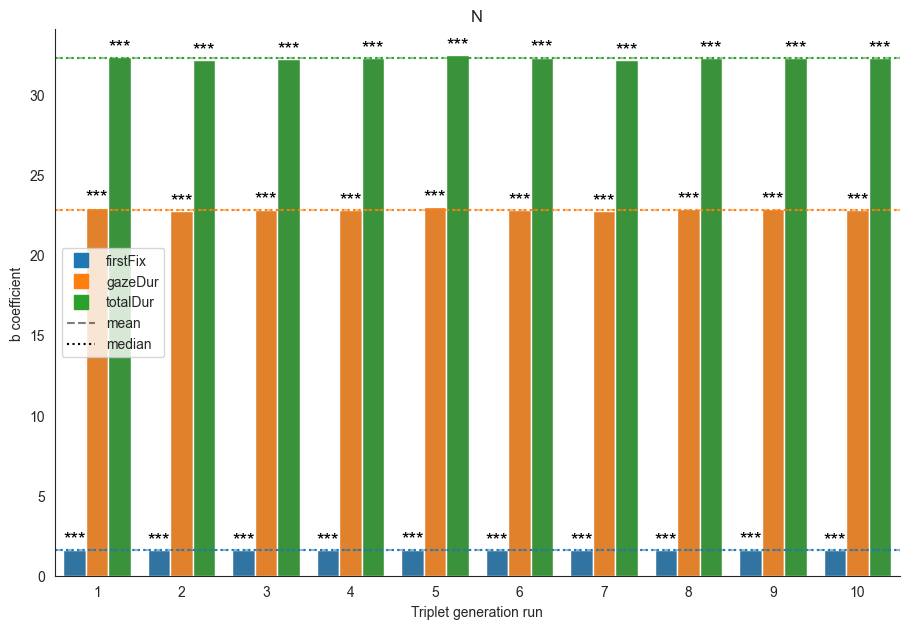

<Figure size 640x480 with 0 Axes>

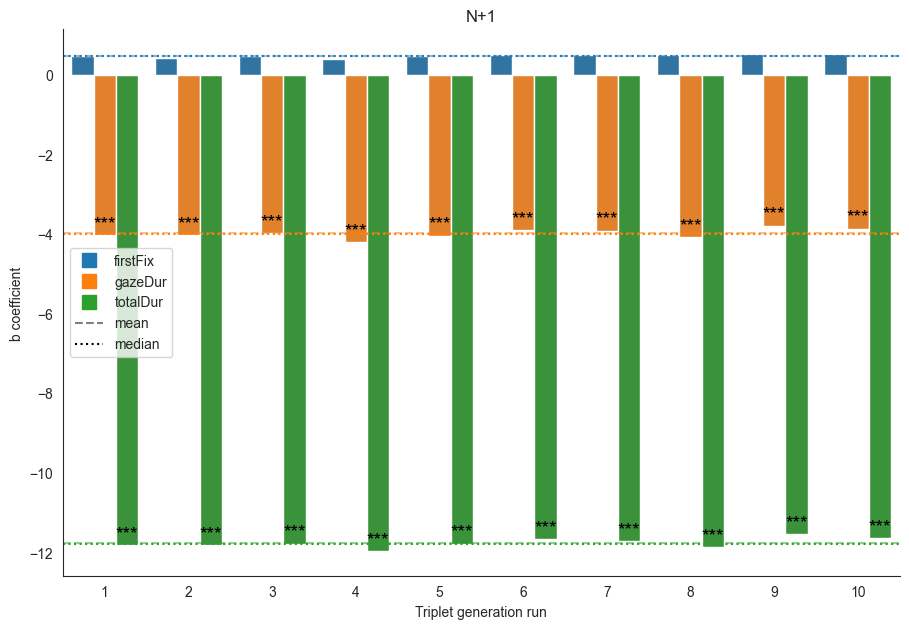

<Figure size 640x480 with 0 Axes>

In [48]:
# Beta coefficients over runs per eye mov measure
n_runs = 10
corpus = 'provo'
model = 'gpt-4o-mini'
IV = 'length'
DV = ['firstFix', 'gazeDur', 'totalDur']
model_types = ['_MinusOne', '', '_PlusOne'] # _MinusOne, _PlusOne, Int, ''
model_type_map = {'':'N',
                  '_MinusOne': 'N-1',
                  '_PlusOne': 'N+1'}
level = '' # _paragraph or _article for onestop

for model_type in model_types:

    coefficients, p_values, runs, eye_movs = [], [], [], []

    for eye_mov_measure in DV:

        for run in range(1, n_runs+1):

            stats_df = pd.read_csv(f'../data/analysis/{model}/{corpus}/lmer_{eye_mov_measure}{model_type}_triplet_added_{run}{level}.csv')
            coefficient = stats_df[stats_df['term']==IV]['estimate'].values[0]
            p_value =stats_df[stats_df['term']==IV]['p.value'].values[0]
            coefficients.append(coefficient)
            p_values.append(p_value)
            runs.append(run)
            eye_movs.append(eye_mov_measure)

    sns.set_style('white')
    # plot bars
    plot_df = pd.DataFrame({'run': runs, 'coefficient': coefficients, 'p_value': p_values, 'eye_movement_measure': eye_movs})
    graph = sns.catplot(data=plot_df, x=runs, y=coefficients, hue=eye_movs, kind='bar', height=6, aspect=1.5, legend=False)

    # add significance asterisks
    p_thresholds = [(0.001, '***'), (0.01, '**'), (0.05, '*')]
    ax = graph.ax
    for bar, p_val in zip(ax.patches, plot_df['p_value']):
        significance = ''
        for threshold, symbol in [(0.001, '***'), (0.01, '**'), (0.05, '*')]:
            if p_val < threshold:
                significance = symbol
                break
        if significance:
            x = bar.get_x() + bar.get_width() / 2  # center of the bar
            y = bar.get_height() # top of the bar
            ax.text(x, y + 0.05, significance, ha='center', va='bottom', fontsize=14, color='black')

    # add horizontal lines for mean and median
    y_positions = {}
    for i, eye_mov in enumerate(DV):
        subset = plot_df[plot_df['eye_movement_measure'] == eye_mov]
        mean_val = subset['coefficient'].mean()
        median_val = subset['coefficient'].median()
        ax.axhline(mean_val, color=f'C{i}', linestyle='--', linewidth=1.5, alpha=0.5)
        ax.axhline(median_val, color=f'C{i}', linestyle=':', linewidth=1.5)
        # add secondary legend for line styles
        hue_handles = [mlines.Line2D([], [], color=f'C{i}', marker='s', linestyle='None', markersize=10, label=eye_mov) for i, eye_mov in enumerate(DV)]
        mean_line = mlines.Line2D([], [], color='black', linestyle='--', label='mean', alpha=0.5)
        median_line = mlines.Line2D([], [], color='black', linestyle=':', label='median')
        # handles, labels = ax.get_legend_handles_labels()
        # handles.extend([mean_line, median_line])
        # labels.extend(['mean', 'median'])
        handles = hue_handles + [mean_line, median_line]
        labels = [eye_mov for eye_mov in DV] + ['mean', 'median']
        ax.legend(handles=handles, labels=labels)

    # add extra info graph
    plt.title(f'{model_type_map[model_type]}')
    plt.xlabel('Triplet generation run')
    plt.ylabel('b coefficient')
    # plt.tight_layout()
    plt.savefig(f'../data/analysis/{model}/{corpus}/beta_coeff_runs{model_type}_{IV}.png', dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.clf()

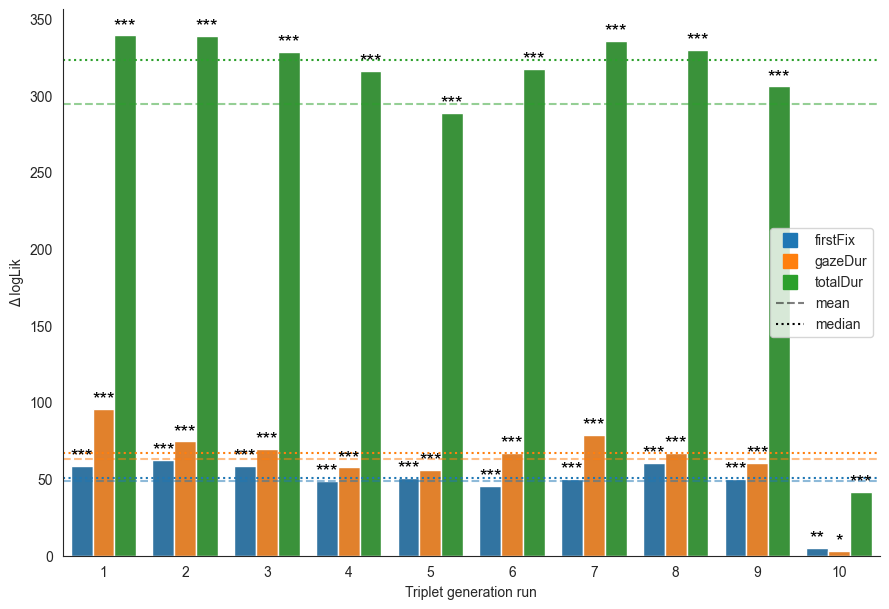

<Figure size 640x480 with 0 Axes>

In [45]:
# a graph similar to the above but with loglik, AIC and significance when comparing main model with baseline (no triplet activation)
# you want diff in loglik to be positive, and diff in AIC to be negative (if full model - baseline).
n_runs = 10
corpus = 'onestop'
model = 'gpt-4o-mini'
DV = ['firstFix', 'gazeDur', 'totalDur']
model_type = '' # Int
measure = 'logLik'  # 'logLik', 'AIC'
model_type_map = {'':'N',
                  '_MinusOne': 'N-1',
                  '_PlusOne': 'N+1'}
level = '_paragraph' # _paragraph or _article for onestop

values, p_values, runs, eye_movs = [], [], [], []

for eye_mov_measure in DV:

    for run in range(1, n_runs+1):

        stats_df = pd.read_csv(f'../data/analysis/{model}/{corpus}/anova_{eye_mov_measure}{model_type}_{run}{level}.csv')
        if measure == 'AIC':
            diff = stats_df[measure].values[-1] - stats_df[measure].values[0]
        elif measure == 'logLik':
            diff = stats_df[measure].values[-1] - stats_df[measure].values[0]
        else:
            raise ValueError(f'measure must be "AIC" or "loglik"')
        p_value = stats_df['Pr(>Chisq)'].values[-1]
        values.append(diff)
        p_values.append(p_value)
        runs.append(run)
        eye_movs.append(eye_mov_measure)

sns.set_style('white')
# plot bars
plot_df = pd.DataFrame({'run': runs, f'change-in-{measure}': values, 'p_value': p_values, 'eye_movement_measure': eye_movs})
graph = sns.catplot(data=plot_df, x=runs, y=f'change-in-{measure}', hue=eye_movs, kind='bar', height=6, aspect=1.5, legend=False)

# add significance asterisks
p_thresholds = [(0.001, '***'), (0.01, '**'), (0.05, '*')]
ax = graph.ax
for bar, p_val in zip(ax.patches, plot_df['p_value']):
    significance = ''
    for threshold, symbol in [(0.001, '***'), (0.01, '**'), (0.05, '*')]:
        if p_val < threshold:
            significance = symbol
            break
    if significance:
        x = bar.get_x() + bar.get_width() / 2  # center of the bar
        y = bar.get_height() # top of the bar
        ax.text(x, y + 0.05, significance, ha='center', va='bottom', fontsize=14, color='black')

# add horizontal lines for mean and median
y_positions = {}
for i, eye_mov in enumerate(DV):
    subset = plot_df[plot_df['eye_movement_measure'] == eye_mov]
    mean_val = subset[f'change-in-{measure}'].mean()
    median_val = subset[f'change-in-{measure}'].median()
    ax.axhline(mean_val, color=f'C{i}', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axhline(median_val, color=f'C{i}', linestyle=':', linewidth=1.5)
    # add secondary legend for line styles
    hue_handles = [mlines.Line2D([], [], color=f'C{i}', marker='s', linestyle='None', markersize=10, label=eye_mov) for i, eye_mov in enumerate(DV)]
    mean_line = mlines.Line2D([], [], color='black', linestyle='--', label='mean', alpha=0.5)
    median_line = mlines.Line2D([], [], color='black', linestyle=':', label='median')
    # handles, labels = ax.get_legend_handles_labels()
    # handles.extend([mean_line, median_line])
    # labels.extend(['mean', 'median'])
    handles = hue_handles + [mean_line, median_line]
    labels = [eye_mov for eye_mov in DV] + ['mean', 'median']
    ax.legend(handles=handles, labels=labels)

# add extra info graph
# plt.title(f'{model_type_map[model_type]}')
plt.xlabel('Triplet generation run')
plt.ylabel(f'Δ {measure}')
# plt.tight_layout()
plt.savefig(f'../data/analysis/{model}/{corpus}/{measure}_runs{model_type}.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

In [21]:
# Find median model
# Provo: N-1 = 4; N = 9; N+1 = 5
# MECO: N-1 = 10; N = 6; N+1 = 3
# OneStop: N-1 = 7; N = 6; N+1 = 1

n_runs = 10
corpus = 'onestop'
model = 'gpt-4o-mini'
IV = 'triplet_added'
DV = ['firstFix', 'gazeDur', 'totalDur']
model_type = '_PlusOne' # _MinusOne, _PlusOne, Int
level = '_paragraph' # _article, _paragraph, or '' for meco

runs = []

for run in range(1, n_runs+1):

    coefficients = []

    for eye_mov_measure in DV:

        filepath = f'../data/analysis/{model}/{corpus}/lmer_{eye_mov_measure}{model_type}_triplet_added_{run}{level}.csv'
        stats_df = pd.read_csv(filepath)
        # print(filepath)
        coefficient = stats_df[stats_df['term']==IV]['estimate'].values[0]
        coefficients.append(coefficient)

    mean_coefficient = np.mean(coefficients)
    runs.append((mean_coefficient, run))

# find run with median mean coefficient
median_run = sorted(runs, key=lambda x: x[0])[len(runs)//2][1]
print(f'Median run is {median_run}')

Median run is 1


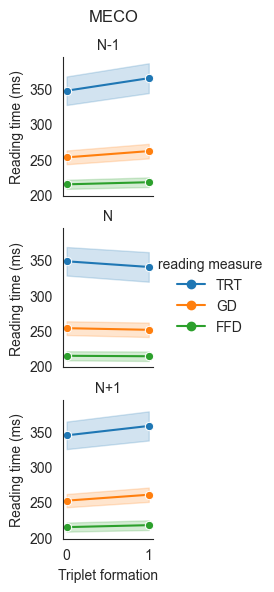

<Figure size 640x480 with 0 Axes>

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

corpus = 'meco'
corpus_map = {
    'provo': 'Provo',
    'meco': 'MECO',
    'onestop': 'OneStop',
}
DV = ['totalDur', 'gazeDur', 'firstFix']
dv_map = {'firstFix': 'FFD',
          'gazeDur': 'GD',
          'totalDur': 'TRT'}
stat_models = ['N-1', 'N', 'N+1']
iv = 'triplet_added'
iv_map = {'triplet_added':'triplet formation'}

all_datasets = []
for stat_model in stat_models:
    for dv in DV:
        model_type = ''
        if stat_model == 'N+1': model_type = '_PlusOne'
        elif stat_model == 'N-1': model_type = '_MinusOne'
        filepath = f'../data/analysis/{model}/{corpus}/predicted_marginal_{iv}_{dv}{model_type}.csv'
        subset_data = pd.read_csv(filepath)
        subset_data['stat model'] = [stat_model for i in range(len(subset_data))]
        subset_data['reading measure'] = [dv_map[dv] for i in range(len(subset_data))]
        all_datasets.append(subset_data)

df = pd.concat(all_datasets, axis=0)

graph = sns.relplot(df, x='x', y='predicted', hue='reading measure', col="stat model", kind='line', height=2, aspect=1.0, col_wrap=1, marker='o', legend=True)

# add confidence intervals
hue_levels = df['reading measure'].unique()
palette = sns.color_palette(n_colors=len(hue_levels))
color_map = dict(zip(hue_levels, palette))
for (predictor_val), ax in graph.axes_dict.items():
    df_sub = df[df['stat model'] == predictor_val]
    for corpus_val, df_line in df_sub.groupby('reading measure'):
        ax.fill_between(df_line['x'],
                        df_line['conf.low'],
                        df_line['conf.high'],
                        color=color_map[corpus_val],
                        alpha=0.2)

graph.set_axis_labels("Triplet formation", "Reading time (ms)")
graph.set_titles("{col_name}")
# set big title
graph.fig.suptitle(corpus_map[corpus])
# adjust location of graphs so title is not on top of other text
graph.fig.subplots_adjust(top=.90)

plt.savefig(f'../data/analysis/gpt-4o-mini/{corpus}/predicted_marginal_effects_triplet_added.png', dpi=300, bbox_inches="tight")
plt.show()
plt.clf()

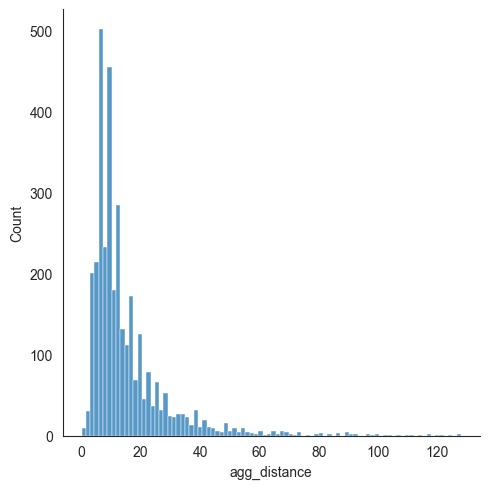

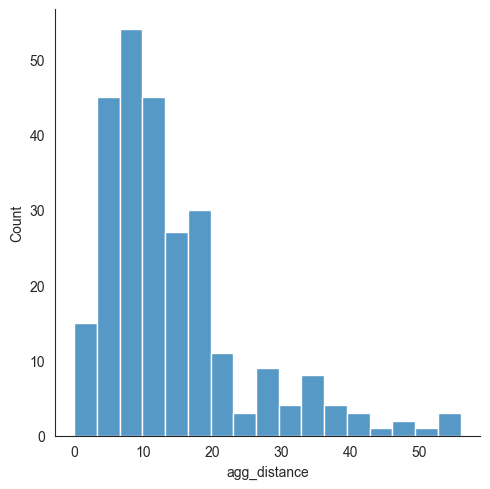

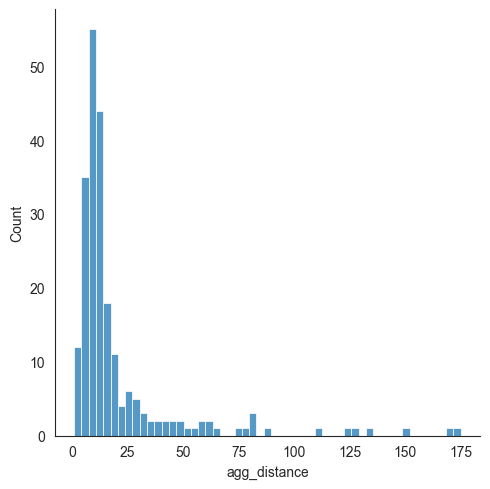

In [85]:
# check distribution of distance between triplet constituents
run = 1
corpus = 'onestop'
df = pd.read_csv(f'../data/output/gpt-4o-mini/{corpus}/{corpus}_words_plus_triplets_gpt-4o-mini_{run}_dist.csv')
df = df[df['triplet_added']==1]
sns.displot(data=df, x='agg_distance')
run = 1
corpus = 'provo'
df = pd.read_csv(f'../data/output/gpt-4o-mini/{corpus}/{corpus}_words_plus_triplets_gpt-4o-mini_{run}_dist.csv')
df = df[df['triplet_added']==1]
sns.displot(data=df, x='agg_distance')
run = 1
corpus = 'meco'
df = pd.read_csv(f'../data/output/gpt-4o-mini/{corpus}/{corpus}_words_plus_triplets_gpt-4o-mini_{run}_dist.csv')
df = df[df['triplet_added']==1]
sns.displot(data=df, x='agg_distance')